### Objetivos do Notebook

Notebook reponsável por extrair as tabelas de origem do datamart de STI armazenadas na API SGT e salvar esses dados no formato Parquet no bucket bronze do MinIO.

### Data Owner
Rodrigo Souza - rodrigo.souza@sfiemt.ind.br

### Origens extraídas do SGT
As seguintes tabelas serão extraídas da API SGT:

- **sti_atendimentos_sgt**

### Local de destino no bucket bronze
Os datasets resultantes gerados pela extração do notebook serão armazenados no bucket bronze do MinIO no formato Parquet, seguindo a estrutura de diretórios e nomes de arquivos baseados na data de execução do notebook.

- **sti_atendimentos_sgt:** bronze/sti/apisgt/sti_atendimentos_sgt/{data_execucao}/sti_atendimentos_sgt_{data_execucao}.parquet

### Linhagem de dados
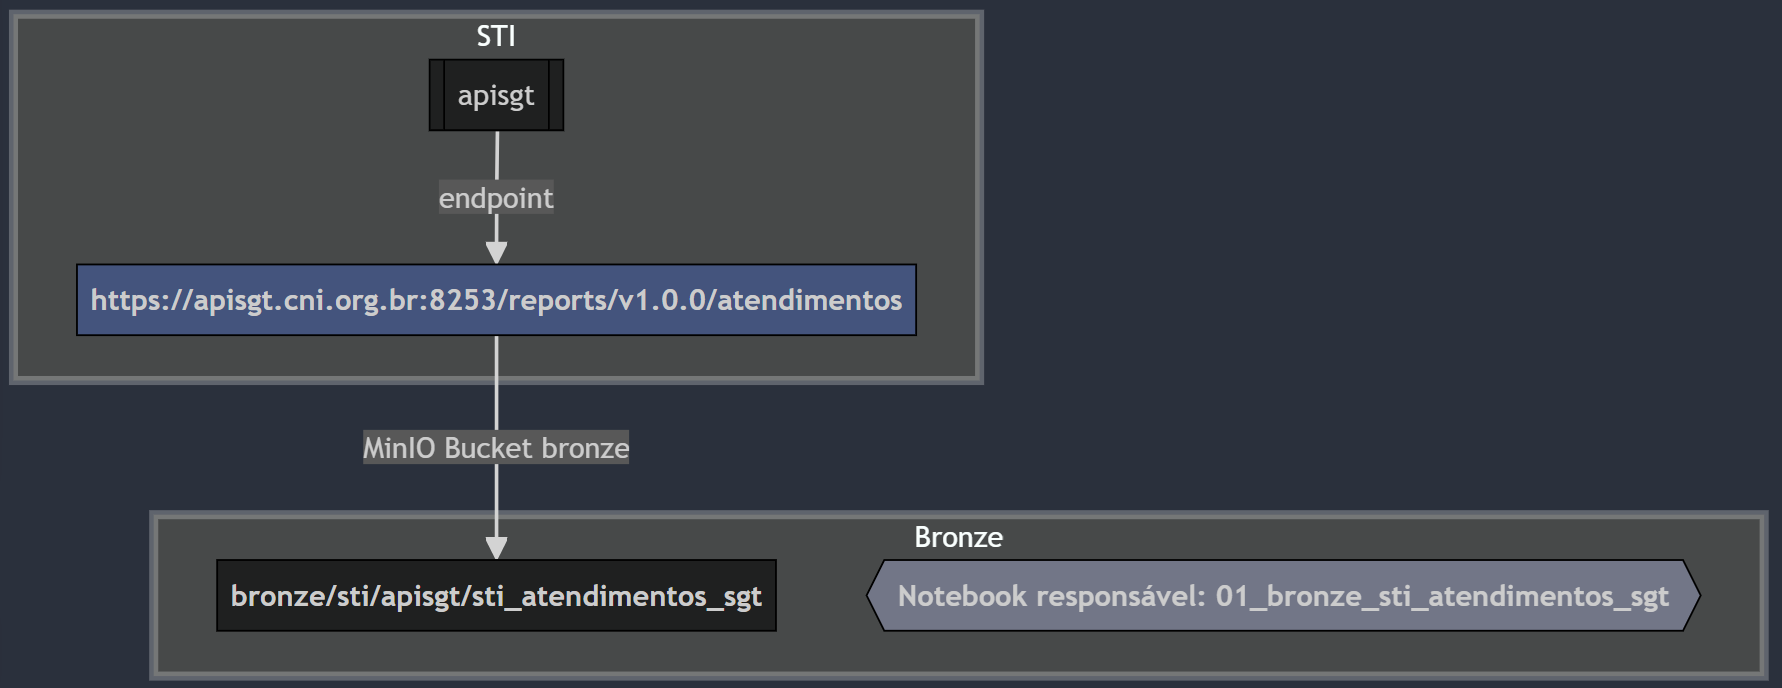

# Bibliotecas necessárias

In [5]:
import os
from pyspark.sql import SparkSession
from datetime import datetime, timedelta
from crawler_sti import create_df,insert_datalake

tabela = 'sti_atendimentos_sgt'
endpoint_antigo = 'https://apisgt.cni.org.br:8253/reports/v1.0.0/atendimentos'
endpoint_novo = 'https://wso2.isitics.com/reports/v1.0.0/atendimentos'

# Cricação da variáveis necessárias

In [6]:
#Último x dias
#dias = 5
#start_date = datetime.now() - timedelta(days=dias)
#date = start_date.strftime('%Y%m%d')

# Data Atul
#date_now = datetime.now().strftime('%Y%m%d')

#Data específica
date = '20230101'

In [ ]:
https://wso2.isitics.com/reports/v1.0.0/atendimentos

# Extração

In [7]:
df = create_df(endpoint, date, tabela)

/opt/conda/lib/python3.11/site-packages/urllib3/connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'wso2.isitics.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


DataFrame criado para sti_atendimentos_sgt na data 2024-11-12


In [8]:
df.count()

5141

# Gravação no datalake

In [4]:
insert_datalake(df, tabela)

Removendo arquivos do Bucket
Enviando sti_atendimentos_sgt para o Bucket bronze do minIO
